In [1]:
import pandas as pd
import numpy as np
import os



target_col = "Dropout"

df = pd.read_csv("data/balanced_dropout_dataset.csv")
print(df.shape)
df.head()

(4482, 18)


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Year of study,Department,Parental_Education,Dropout
0,19.2,0,25000.0,1,4.08,76.8,5,20.7,0,0,9.3,2.26,2.42,2.40,2,Engineering,Bachelor,1
1,21.3,1,36634.0,0,2.57,86.2,1,41.4,0,0,6.2,1.98,1.70,1.70,1,Engineering,High School,0
2,20.6,0,42980.0,1,2.94,78.9,4,45.8,0,0,6.2,1.65,1.53,1.56,4,Science,Bachelor,1
3,21.4,1,25000.0,1,4.94,75.5,1,51.4,1,1,5.3,2.18,2.20,2.20,1,Business,High School,1
4,21.5,1,97830.0,1,4.48,77.6,2,31.5,1,1,6.0,0.46,0.92,0.92,1,CS,High School,1


In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Year of study']
Categorical: ['Department', 'Parental_Education']


In [3]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(df[target_col])

corr_with_target = df[numeric_cols].apply(lambda col: col.corr(pd.Series(y_encoded)))
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)
print(corr_with_target)

GPA                     -0.538197
Semester_GPA            -0.524609
CGPA                    -0.523866
Stress_Index             0.297623
Attendance_Rate         -0.202034
Study_Hours_per_Day     -0.106083
Assignment_Delay_Days    0.092857
Part_Time_Job            0.052162
Internet_Access         -0.047582
Travel_Time_Minutes      0.032691
Gender                  -0.020528
Year of study            0.019026
Age                      0.017598
Scholarship             -0.002812
Family_Income            0.002584
dtype: float64


In [4]:
from sklearn.feature_selection import mutual_info_classif

X_numeric = df[numeric_cols].fillna(df[numeric_cols].median())
mi_scores = mutual_info_classif(X_numeric, y_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)
print(mi_series)

CGPA                     0.161077
GPA                      0.160584
Semester_GPA             0.152754
Stress_Index             0.050860
Attendance_Rate          0.017371
Year of study            0.006628
Family_Income            0.003406
Study_Hours_per_Day      0.001923
Scholarship              0.001842
Assignment_Delay_Days    0.000913
Age                      0.000000
Internet_Access          0.000000
Gender                   0.000000
Travel_Time_Minutes      0.000000
Part_Time_Job            0.000000
dtype: float64


In [5]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cat_scores = {}
for col in categorical_cols:
    cat_scores[col] = cramers_v(df[col].astype(str), df[target_col].astype(str))

cat_scores_series = pd.Series(cat_scores).sort_values(ascending=False)
print(cat_scores_series)

Parental_Education    0.024187
Department            0.007675
dtype: float64


In [6]:

CORR_THRESHOLD = 0.05
MI_THRESHOLD = 0.01
CRAMERS_V_THRESHOLD = 0.05

relevant_numeric = corr_with_target[
    (corr_with_target.abs() >= CORR_THRESHOLD) | (mi_series >= MI_THRESHOLD)
].index.tolist()

relevant_categorical = cat_scores_series[
    cat_scores_series >= CRAMERS_V_THRESHOLD
].index.tolist()

relevant_cols = relevant_numeric + relevant_categorical + [target_col]
print("Relevant columns kept:", relevant_cols)
print("Dropped columns:", [c for c in df.columns if c not in relevant_cols])

df_relevant = df[relevant_cols]
df_relevant.shape

Relevant columns kept: ['GPA', 'Semester_GPA', 'CGPA', 'Stress_Index', 'Attendance_Rate', 'Study_Hours_per_Day', 'Assignment_Delay_Days', 'Part_Time_Job', 'Dropout']
Dropped columns: ['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Travel_Time_Minutes', 'Scholarship', 'Year of study', 'Department', 'Parental_Education']


(4482, 9)

In [7]:
os.makedirs("data", exist_ok=True)
df_relevant.to_csv("data/relevant_cols.csv", index=False)
print("Saved to data/relevant_cols.csv")

Saved to data/relevant_cols.csv


In [8]:
from sklearn.model_selection import train_test_split

df_model = df_relevant.copy()

for col in relevant_categorical:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=[target_col])
y = LabelEncoder().fit_transform(df_model[target_col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(3585, 8) (897, 8)


In [9]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


              precision    recall  f1-score   support

           0       0.73      0.73      0.73       449
           1       0.73      0.73      0.73       448

    accuracy                           0.73       897
   macro avg       0.73      0.73      0.73       897
weighted avg       0.73      0.73      0.73       897

ROC-AUC: 0.8101187161947183


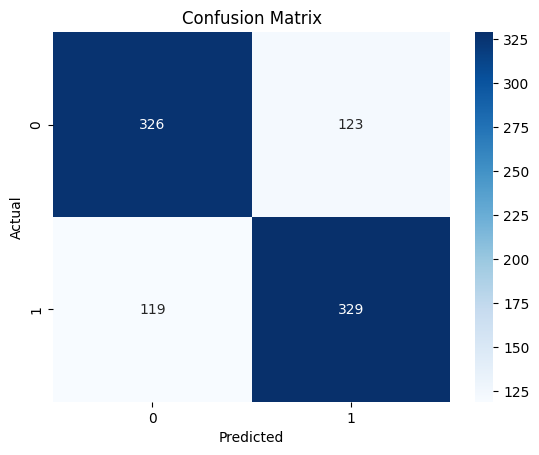

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

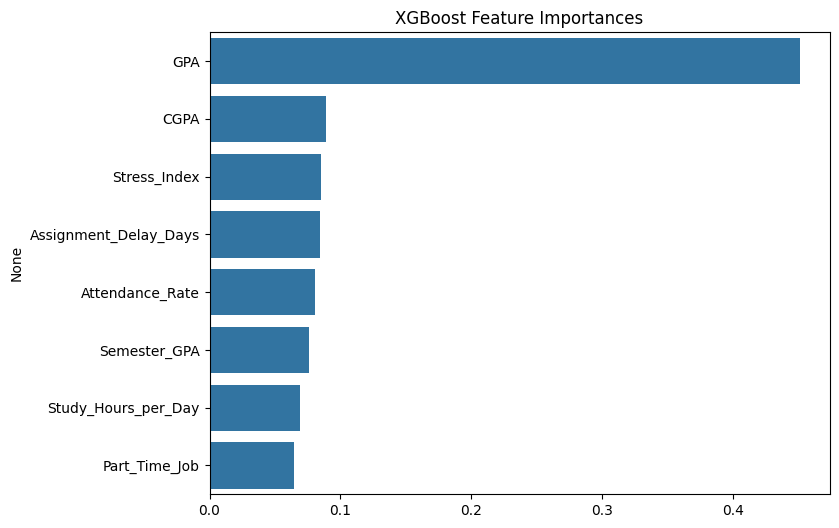

GPA                      0.451172
CGPA                     0.088865
Stress_Index             0.084818
Assignment_Delay_Days    0.084378
Attendance_Rate          0.080666
Semester_GPA             0.076122
Study_Hours_per_Day      0.069481
Part_Time_Job            0.064499
dtype: float32

In [11]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("XGBoost Feature Importances")
plt.show()

importances

In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best AUC:", search.best_score_)

best_model = search.best_estimator_

Best params: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best AUC: 0.8198993168484773


In [13]:
best_model = XGBClassifier(
    subsample=1.0,
    n_estimators=100,
    min_child_weight=5,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

best_model.fit(X_train, y_train)

y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       449
           1       0.76      0.76      0.76       448

    accuracy                           0.76       897
   macro avg       0.76      0.76      0.76       897
weighted avg       0.76      0.76      0.76       897

ROC-AUC: 0.8302303730512249


In [14]:
import pickle
import os
from datetime import datetime

os.makedirs("models", exist_ok=True)


model_name = f"xgb_dropout_relevant_cols.pkl"
model_path = os.path.join("models", model_name)

with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"Model saved to: {model_path}")

Model saved to: models\xgb_dropout_relevant_cols.pkl


In [15]:
train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, y_proba_best)
print(f"Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")

Train AUC: 0.8450 | Test AUC: 0.8302
